## Shopper Spectrum

## Customer Segmentation and Product Recommendation using Machine Learning

## 1. Import Required Libraries

In [118]:
import pandas as pd
import numpy as np
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Load original dataset
df = pd.read_csv(r"C:\Users\cbec\OneDrive\Desktop\intern\Projects\Project -4\online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [120]:
df.shape

(541909, 8)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [124]:
df.duplicated().sum()

5268

In [126]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 2.  Data Cleaning and Preprocessing

In [128]:

data = df.copy()

data = data.dropna(subset=["CustomerID"])
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]
data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0]
data = data.drop_duplicates()

data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["Description"] = data["Description"].astype(str).str.strip()

## 3. Feature Engineering

In [130]:
#create the first feature
data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [150]:
data.shape

(392692, 9)

 ## 4.Exploratory Data Analysis (EDA)

In [152]:
# 1. RFM Analysis
latest_date = data["InvoiceDate"].max()

rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

In [154]:
# 2. Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])


In [156]:
# 3. KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)

rfm["Cluster"] = clusters


In [158]:
# 4. Cluster mapping
cluster_mapping = {
    0: "Occasional",
    1: "At-Risk",
    2: "High-Value",
    3: "Regular"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_mapping)


In [160]:
# 5. Silhouette score
score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.6162275299061803


In [162]:
# 6. Product recommendation system
customer_product = data.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

product_similarity = cosine_similarity(customer_product.T)

similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)


In [164]:
# 7. Save top 5 recommendation dictionary
top5_recommendations = {}

for product in similarity_df.columns:
    top5_recommendations[product] = (
        similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:6]
        .to_dict()
    )

In [170]:
# 8. Product names
product_names = list(similarity_df.columns)


In [172]:
# 9. Save all required files
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("cluster_mapping.pkl", "wb") as f:
    pickle.dump(cluster_mapping, f)

with open("product_names.pkl", "wb") as f:
    pickle.dump(product_names, f)

with open("top5_recommendations.pkl", "wb") as f:
    pickle.dump(top5_recommendations, f)

print("All required files saved successfully!")
print("Cleaned data rows:", data.shape)
print("RFM rows:", rfm.shape)
print("Total products:", len(product_names))

All required files saved successfully!
Cleaned data rows: (392692, 9)
RFM rows: (4338, 5)
Total products: 3866


In [174]:
# 10. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [176]:
# 11. Load Cleaned Dataset
data = pd.read_csv("cleaned_online_retail.csv")

data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [178]:
# 12. Dataset Information
print(data.shape)

data.info()

data.describe()

(392692, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 27.0+ MB


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2023-07-10 19:13:07.771892224,3.125914,15287.843865,22.631500
min,536365.000000,1.000000,2022-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,2023-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,2023-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,2023-10-20 12:53:00,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,2023-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099224


In [180]:
# 13 Missing Values
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

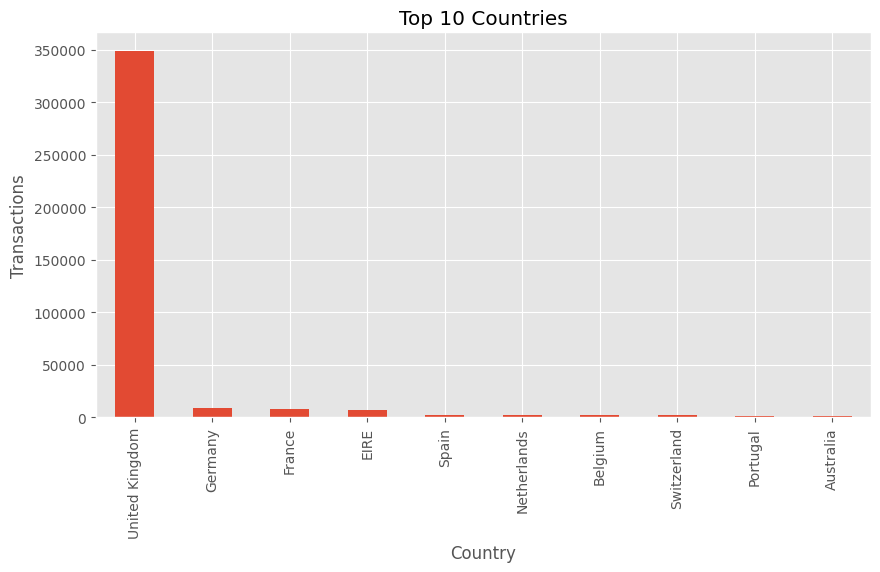

In [182]:
# 14. Top 10 Countries
top_country = data["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_country.plot(kind="bar")

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Transactions")

plt.show()

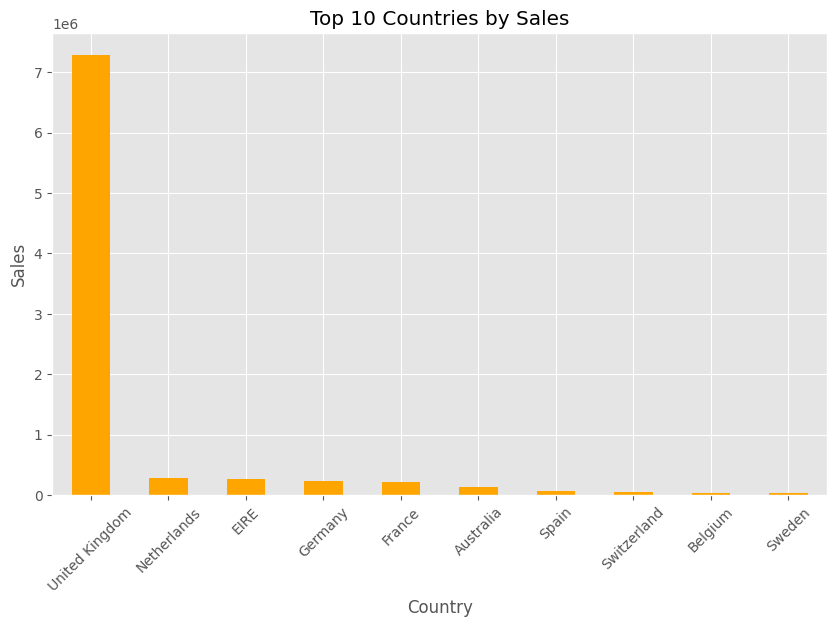

In [192]:
## Top 10 Countries by Sales
country_sales = (
    data.groupby("Country")["TotalAmount"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
)

country_sales

plt.figure(figsize=(10,6))

country_sales.plot(kind='bar', color='orange')

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

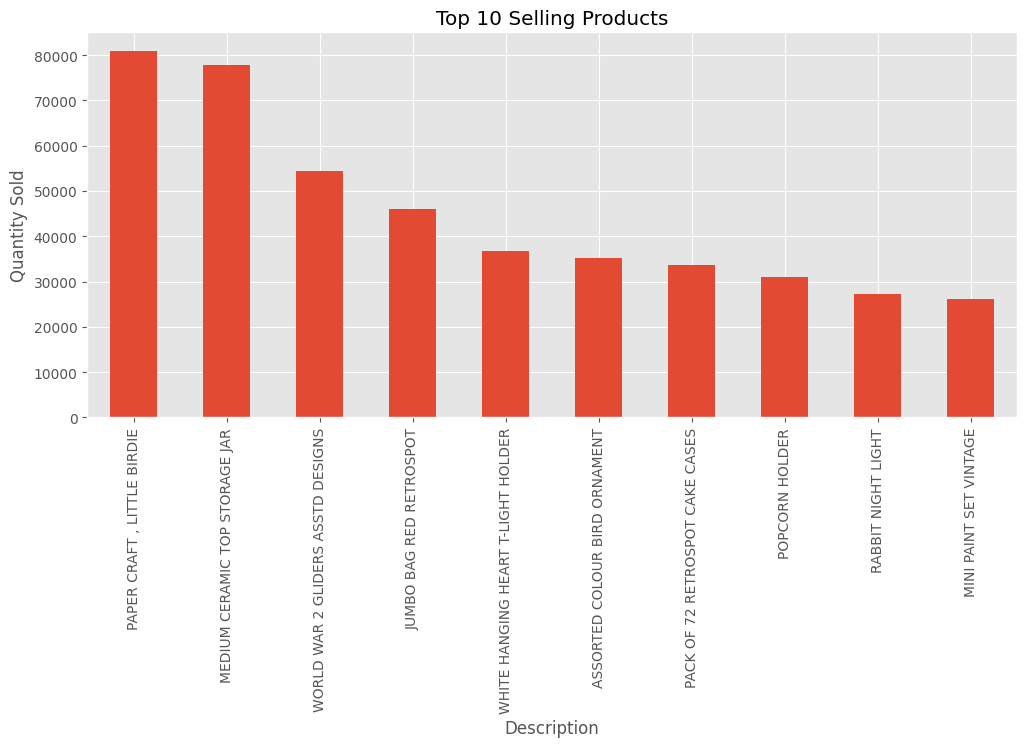

In [38]:
# 15.  Top 10 Selling Products
top_products = data.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")

plt.show()

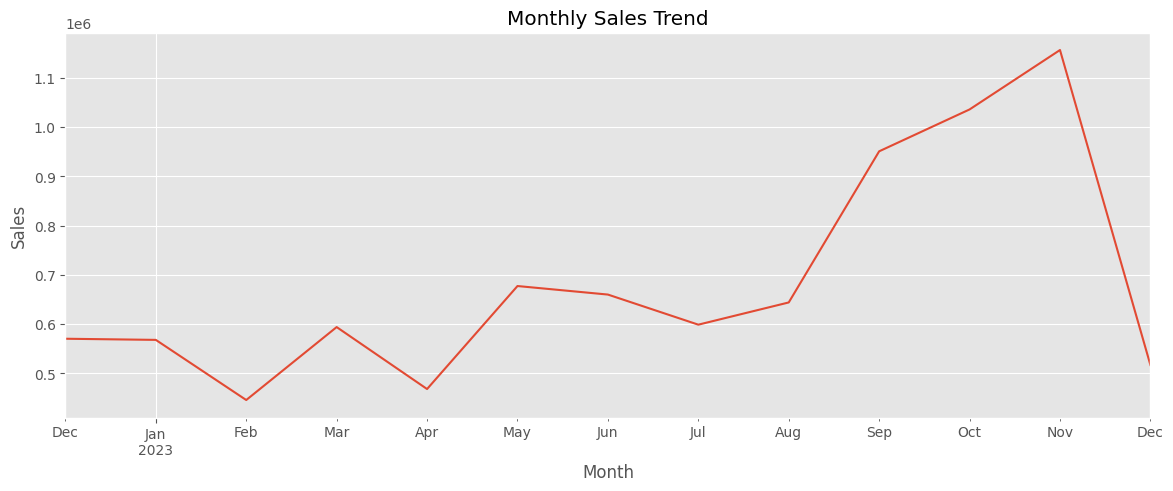

In [184]:
#  16.Monthly Sales
data["Month"] = data["InvoiceDate"].dt.to_period("M")

monthly_sales = data.groupby("Month")["TotalAmount"].sum()

plt.figure(figsize=(14,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.show()

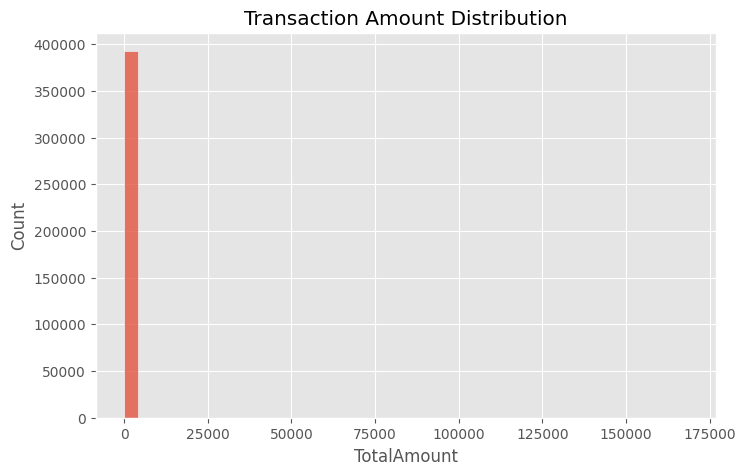

In [186]:
# 17. Distribution of Transaction Amount
plt.figure(figsize=(8,5))

sns.histplot(data["TotalAmount"], bins=40)

plt.title("Transaction Amount Distribution")

plt.show()

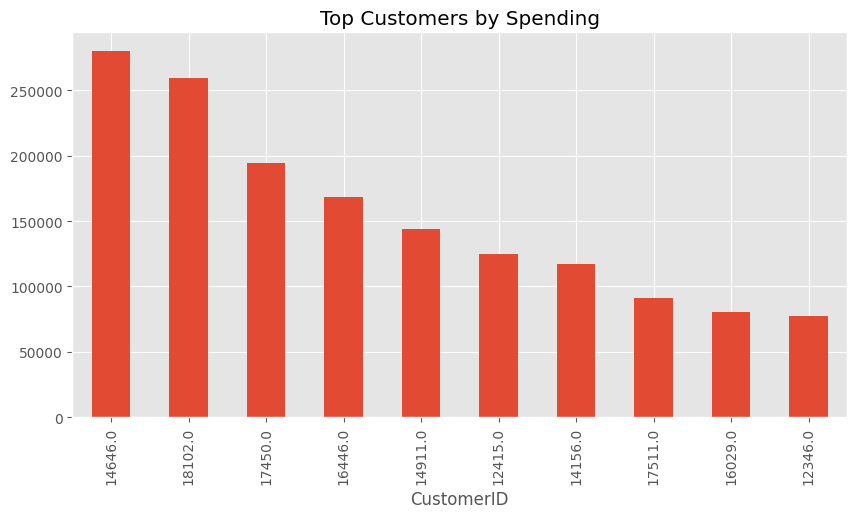

In [188]:
# 18. Top Customers
top_customer = data.groupby("CustomerID")["TotalAmount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_customer.plot(kind="bar")

plt.title("Top Customers by Spending")

plt.show()

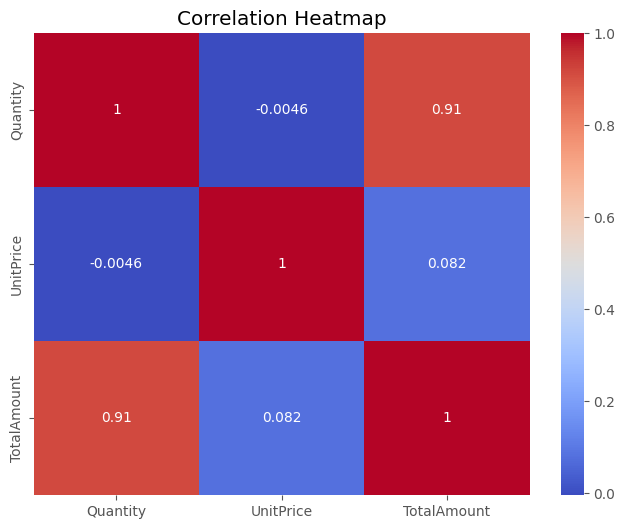

In [46]:
# 19. Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    data[["Quantity","UnitPrice","TotalAmount"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

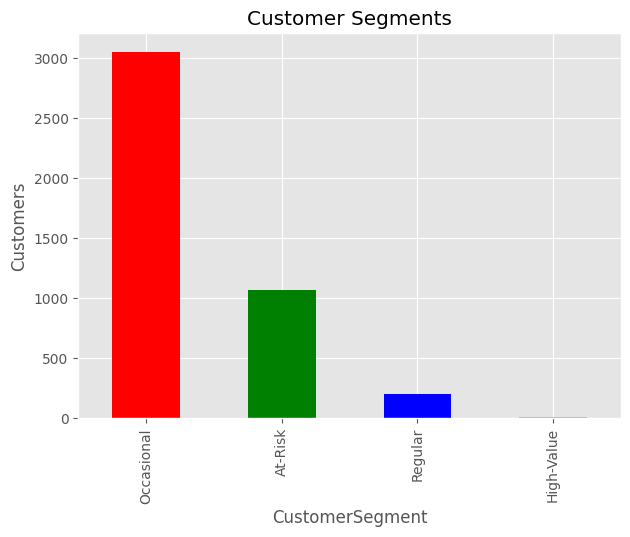

In [48]:
# 20.Customer Segments (after RFM)
segment_count = rfm["CustomerSegment"].value_counts()

plt.figure(figsize=(7,5))

segment_count.plot(kind="bar", color=["red","green","blue","orange"])

plt.title("Customer Segments")

plt.ylabel("Customers")

plt.show()

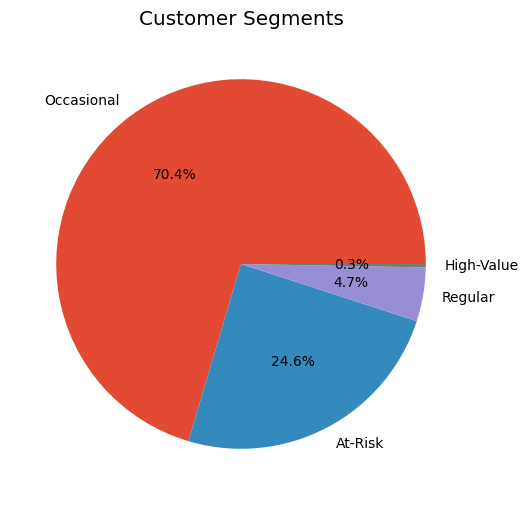

In [50]:
# 21. Customer Segment Pie Chart
plt.figure(figsize=(6,6))

segment_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Customer Segments")

plt.show()

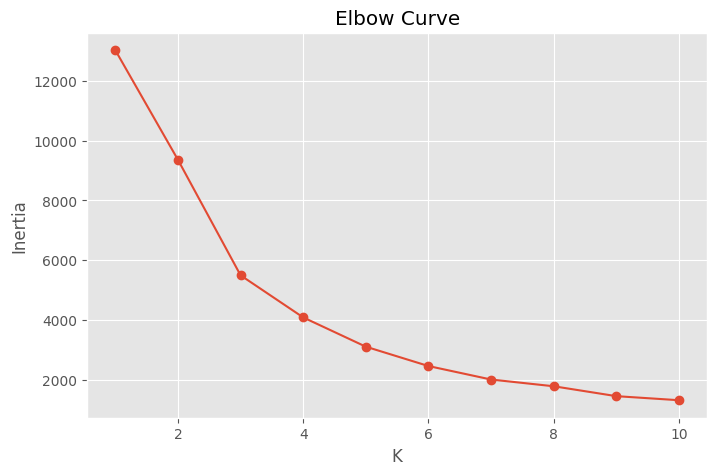

In [52]:
# 22.Elbow Curve
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(rfm_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title("Elbow Curve")

plt.show()

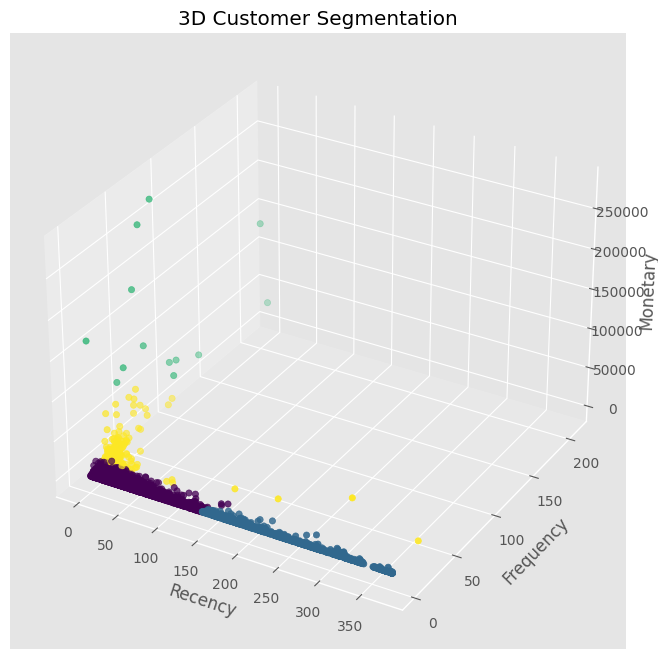

In [54]:
# 23. 3D Customer Segmentation
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    cmap="viridis"
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segmentation")

plt.show()

## Revenue Distribution (Histogram)

Total Revenue: $8,887,208.89


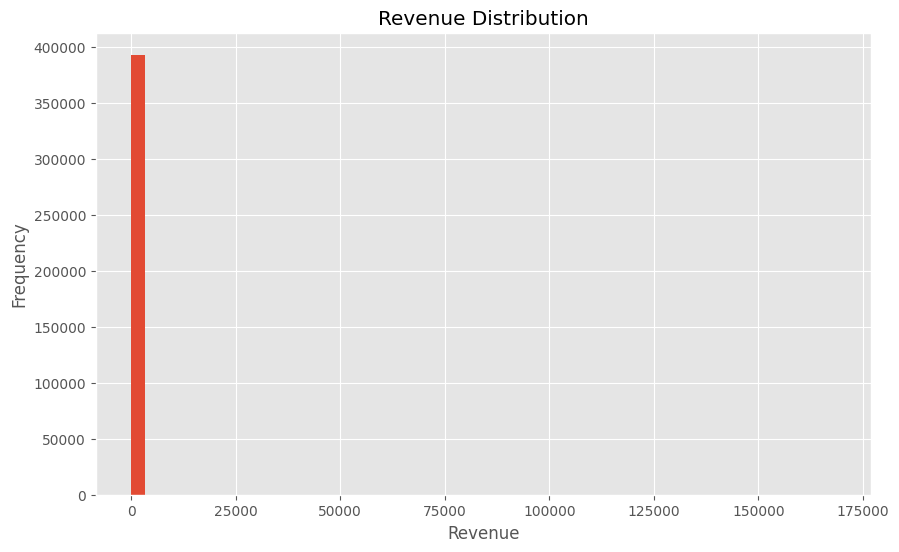

In [195]:
total_revenue = data["TotalAmount"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(data["TotalAmount"], bins=50)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

## Most Active Customers

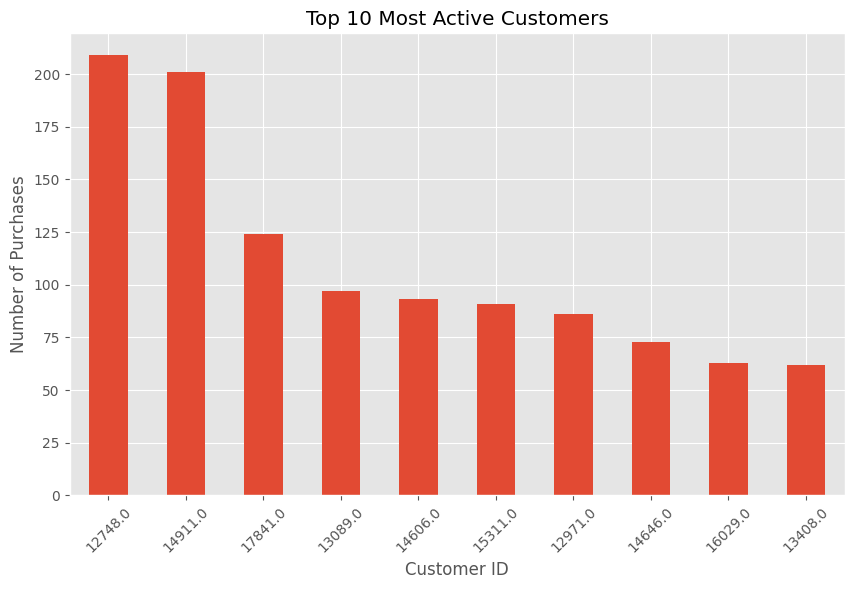

In [203]:
import matplotlib.pyplot as plt

active_customers = (
    data.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

active_customers.plot(kind="bar")

plt.title("Top 10 Most Active Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()